### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(74)

In [14]:
data[data.duplicated(keep=False)].sort_values(by=data.columns.tolist())

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
6968,Home,Alone,Snowy,30,10PM,Restaurant(20-50),2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,0,1,0
7853,Home,Alone,Snowy,30,10PM,Restaurant(20-50),2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,0,1,0
7407,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
8509,Home,Alone,Snowy,30,6PM,Coffee House,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
7406,Home,Alone,Sunny,30,6PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5606,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,below21,Single,...,less1,gt8,1~3,never,1,1,1,0,1,1
6974,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,1
7859,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,1
7414,Work,Alone,Sunny,80,7AM,Restaurant(<20),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1


In [8]:
data['toCoupon_GEQ5min'].value_counts()

toCoupon_GEQ5min
1    12684
Name: count, dtype: int64

In [10]:
data['age'].value_counts()

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [15]:
# Dropping uninformative columns
data = data.drop(columns=['car', 'toCoupon_GEQ5min'])

# Fixing the typo
data = data.rename(columns={'passanger': 'passenger'})

4. What proportion of the total observations chose to accept the coupon?



In [16]:
print(f"Accepted: {data['Y'].sum()}")
print(f"Total: {len(data)}")
print(f"Acceptance rate: {data['Y'].mean():.2%}")

Accepted: 7210
Total: 12684
Acceptance rate: 56.84%


5. Use a bar plot to visualize the `coupon` column.

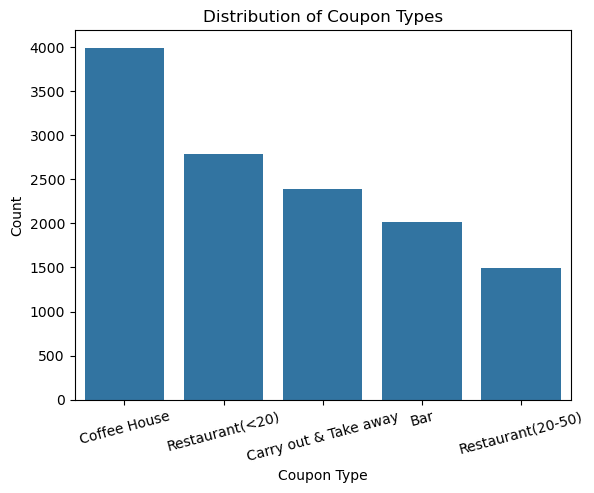

In [20]:
sns.countplot(data=data, x='coupon', order=data['coupon'].value_counts().index)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

6. Use a histogram to visualize the temperature column.

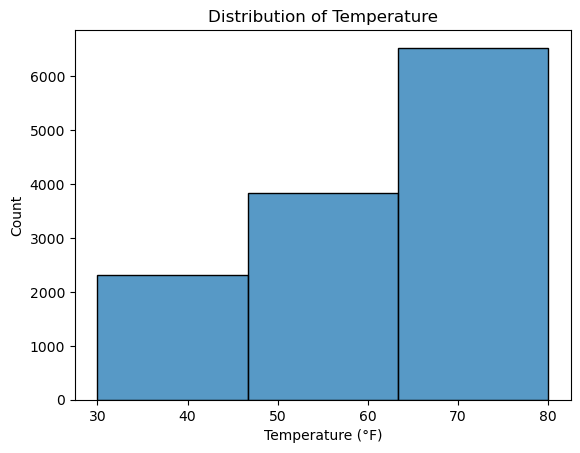

In [23]:
sns.histplot(data=data, x='temperature', bins=3)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [24]:
bar_coupons = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [25]:
print(f"Accepted: {bar_coupons['Y'].sum()}")
print(f"Total: {len(bar_coupons)}")
print(f"Acceptance rate: {bar_coupons['Y'].mean():.2%}")

Accepted: 827
Total: 2017
Acceptance rate: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [26]:
few = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])]['Y'].mean()
more = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()

print(f"3 or fewer visits/month: {few:.2%}")
print(f"More than 3 visits/month: {more:.2%}")

3 or fewer visits/month: 37.06%
More than 3 visits/month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [33]:
# Segment: visits bar more than once a month AND over 25
target = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
]['Y'].mean()

#Everyone else
all_others = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['age'].isin(['26', '31', '36', '41', '46', '50plus']))
    )
]['Y'].mean()

print(f"Bar > 1x/month and age > 25: {target:.2%}")
print(f"All others: {all_others:.2%}")
print("Drivers who go to a bar 1x/month and are over the age of 25 used bar coupons significantly more often than all others")

Bar > 1x/month and age > 25: 69.52%
All others: 33.50%
Drivers who go to a bar 1x/month and are over the age of 25 used bar coupons significantly more often than all others


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [32]:
# Segment: visits bar more than once a month AND passenger is not a kid AND occupation is not farming/fishing/forestry
target = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passenger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]['Y'].mean()

all_others = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['passenger'] != 'Kid(s)') &
        (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
    )
]['Y'].mean()

print(f"Bar > 1x/month, no kid passenger, not farming/fishing/forestry: {target:.2%}")
print(f"All others: {all_others:.2%}")

Bar > 1x/month, no kid passenger, not farming/fishing/forestry: 71.32%
All others: 29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [37]:
# Condition 1: Bars more than once a month, no kid passenger, and not widowed
cond1 = (
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passenger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
)

# Condition 2: Bars more than once a month and under age 30
cond2 = (
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['below21', '21', '26']))
)

# Condition 3: Cheap restaurants more than 4 times a month and income under $50K
cond3 = (
    (bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupons['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))
)

# Compare acceptance rates
target = bar_coupons[cond1 | cond2 | cond3]['Y'].mean()
all_others = bar_coupons[~(cond1 | cond2 | cond3)]['Y'].mean()

# Condition acceptance rates for comparison
print(f"Cond 1 (bar>1x, no kid, not widowed): {bar_coupons[cond1]['Y'].mean():.2%}")
print(f"Cond 2 (bar>1x, under 30):            {bar_coupons[cond2]['Y'].mean():.2%}")
print(f"Cond 3 (cheap restaurant>4x, <$50K):  {bar_coupons[cond3]['Y'].mean():.2%}")
print(f"Combined target segment: {target:.2%}")
print(f"All others:              {all_others:.2%}")

Cond 1 (bar>1x, no kid, not widowed): 71.32%
Cond 2 (bar>1x, under 30):            72.17%
Cond 3 (cheap restaurant>4x, <$50K):  45.35%
Combined target segment: 58.89%
All others:              29.81%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Hypothesis: Drivers Who Accept Bar Coupons

Drivers who are more likely to accept bar coupons tend to be younger (under 30) 
and/or regular bar-goers without kids in the car. Conditions 1 and 2 both show 
acceptance rates above 71%, suggesting that existing bar habits and a social, 
unencumbered lifestyle are the strongest predictors of acceptance. Condition 3's 
lower rate of 45% suggests that income and cheap dining habits alone are weaker 
indicators — budget-conscious drivers may be less inclined toward bars specifically 
even if they're deal-seekers generally. Overall, the combined segment accepts at 
nearly double the rate of all others (58.89% vs. 29.81%), indicating these lifestyle 
factors are meaningful signals. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [39]:
# Segmenting only coffee house coupons
coffee_coupons = data[data['coupon'] == 'Coffee House']

In [40]:
# Overall shape and acceptance rate
print(f"Total coffee house coupons: {len(coffee_coupons)}")
print(f"Acceptance rate: {coffee_coupons['Y'].mean():.2%}")

Total coffee house coupons: 3996
Acceptance rate: 49.92%


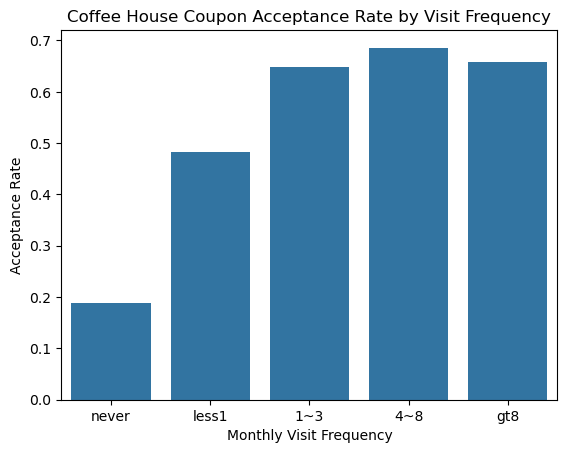

In [42]:
# Acceptance rate by coffee house visit frequency
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']

freq_acceptance = (coffee_coupons.groupby('CoffeeHouse')['Y']
                   .mean()
                   .reindex(freq_order)
                   .reset_index())
freq_acceptance.columns = ['Visit Frequency', 'Acceptance Rate']

sns.barplot(data=freq_acceptance, x='Visit Frequency', y='Acceptance Rate')
plt.title('Coffee House Coupon Acceptance Rate by Visit Frequency')
plt.xlabel('Monthly Visit Frequency')
plt.ylabel('Acceptance Rate')
plt.show()

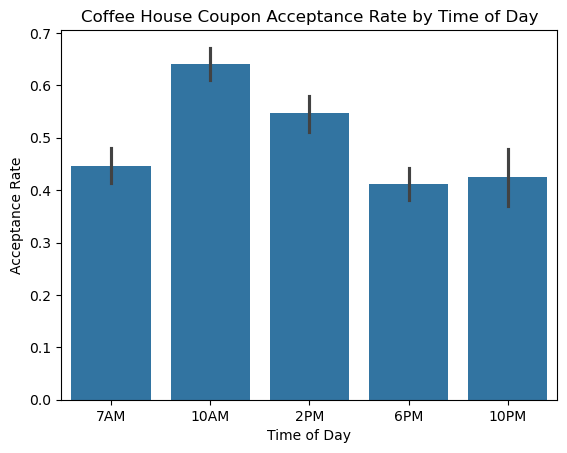

In [45]:
# Acceptance rate by time of day
sns.barplot(data=coffee_coupons, x='time', y='Y', order=['7AM', '10AM', '2PM', '6PM', '10PM'])
plt.title('Coffee House Coupon Acceptance Rate by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Acceptance Rate')
plt.show()

In [46]:
# Segment: visits coffee house more than once a month AND coupon delivered at 10AM
target = coffee_coupons[
    (coffee_coupons['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])) &
    (coffee_coupons['time'] == '10AM')
]['Y'].mean()

all_others = coffee_coupons[
    ~(
        (coffee_coupons['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])) &
        (coffee_coupons['time'] == '10AM')
    )
]['Y'].mean()

print(f"Regular coffee house visitors at 10AM: {target:.2%}")
print(f"All others:                            {all_others:.2%}")

Regular coffee house visitors at 10AM: 81.29%
All others:                            46.27%


### Hypothesis: Drivers Who Accept Coffee House Coupons

Coffee house coupon acceptance is strongly driven by two factors: existing coffee 
house habits and time of day. Drivers who already visit coffee houses regularly 
(more than once a month) show acceptance rates between 65-69%, compared to just 
19% for non-visitors, suggesting that habit is the single strongest predictor.

Time of day also plays a significant role, with 10AM showing the highest acceptance 
rate at 64%, which aligns intuitively with typical coffee consumption patterns. 
Evening hours (6PM, 10PM) drop to around 41-42%, suggesting drivers are far less 
motivated by a coffee coupon later in the day.

When combining both factors — regular visitors receiving a coupon at 10AM — the 
acceptance rate jumps to 81.29%, nearly double the 46.27% rate for all others. 
This suggests that targeting habitual coffee drinkers during morning hours represents 
the highest-value opportunity for coffee house coupon campaigns.

**Next Steps:** Further analysis could explore whether destination (work vs. no urgent 
place) interacts with time of day, and whether age or passenger type adds additional 
predictive value on top of frequency and timing.
